# 03 — Baseline Training

**Goal:** Train a minimal semantic segmentation CNN from scratch to verify the full pipeline runs end-to-end.

---

## What model are we using?

This notebook uses a **very simple 3-layer CNN** as a placeholder.  
Its purpose is to confirm that:
- Data loading works correctly.
- Tensor shapes are correct at every step.
- The loss goes down (even slightly) after one epoch.
- Checkpointing saves and restores weights.

This model will **not** produce good segmentations — that is expected.  
Once the pipeline is verified, replace the model with U-Net, FCN, or DeepLabv3.

> **Prerequisite:** Run notebooks 00–02 first and ensure `pairs` is populated.

In [19]:
import hashlib
import os
import platform
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from src.data_paths import ARTIFACTS_DIR, MODELS_DIR, PROJECT_ROOT, RAW_DATA_DIR, ensure_project_dirs
from src.dataset import AI4MarsDataset, load_pairs_from_manifest
from src.foundation import (
    build_checkpoint_metadata,
    build_split_manifests,
    detect_dataset_root,
    read_manifest_rows,
    sha256_file,
    write_run_record,
)
from src.train_utils import get_device, save_checkpoint, train_one_epoch, evaluate

ensure_project_dirs()

print(f"PyTorch version: {torch.__version__}")

All project directories are ready.
PyTorch version: 2.12.1+cu126


## Step 1 — Load Pairs

In [20]:
DATASET_ROOT = detect_dataset_root(RAW_DATA_DIR)
MANIFEST_DIR = ARTIFACTS_DIR / "manifests"
DATA_SCOPE_VERSION = "msl_navcam_v1"
SPLIT_DIR =  (
    MANIFEST_DIR
    / "splits"
    / DATA_SCOPE_VERSION
)
DATASET_MANIFEST = MANIFEST_DIR / "ai4mars_dataset_manifest.csv"
SPLIT_HASH_MANIFEST = SPLIT_DIR / "split_manifest_hashes_nav.json"

if not DATASET_MANIFEST.exists():
    raise FileNotFoundError(
        f"Canonical dataset manifest missing: {DATASET_MANIFEST}. "
        "Generate/restore artifacts/manifests before running training."
    )

split_manifest_paths = build_split_manifests(
    dataset_manifest_path=DATASET_MANIFEST,
    output_dir=SPLIT_DIR,
    train_ratio=0.80,
    seed=42,
    label_scheme="NAV",
    mission_filter="msl",
    camera_filter="ncam",
)

print(f"Generated scoped manifests under: {SPLIT_DIR}")

for split_name, split_path in sorted(
    split_manifest_paths.items()
):
    print(
        f"{split_name:20s} -> "
        f"{split_path.name}"
    )

if not SPLIT_HASH_MANIFEST.exists():
    raise FileNotFoundError(
        f"Canonical split hash manifest missing: {SPLIT_HASH_MANIFEST}. "
        "Generate/restore artifacts/manifests/splits first."
    )

print(f"Using canonical dataset manifest: {DATASET_MANIFEST}")
for split_name, split_path in sorted(split_manifest_paths.items()):
    print(f"{split_name:20s} -> {split_path.name}")

Generated scoped manifests under: C:\Users\Jacob\AI4Mars\artifacts\manifests\splits\msl_navcam_v1
test_min1_100agree   -> test_min1_100agree_nav.csv
test_min2_100agree   -> test_min2_100agree_nav.csv
test_min3_100agree   -> test_min3_100agree_nav.csv
train                -> train_nav.csv
val                  -> val_nav.csv
Using canonical dataset manifest: C:\Users\Jacob\AI4Mars\artifacts\manifests\ai4mars_dataset_manifest.csv
test_min1_100agree   -> test_min1_100agree_nav.csv
test_min2_100agree   -> test_min2_100agree_nav.csv
test_min3_100agree   -> test_min3_100agree_nav.csv
train                -> train_nav.csv
val                  -> val_nav.csv


In [21]:
EXPECTED_MISSION = "msl"
EXPECTED_CAMERA = "ncam"
EXPECTED_LABEL_SCHEME = "NAV"


for split_name, split_path in sorted(
    split_manifest_paths.items()
):
    rows = read_manifest_rows(split_path)

    invalid_rows = [
        row
        for row in rows
        if row.get("mission") != EXPECTED_MISSION
        or row.get("camera") != EXPECTED_CAMERA
        or row.get("label_scheme") != EXPECTED_LABEL_SCHEME
    ]

    if invalid_rows:
        example = invalid_rows[0]

        raise RuntimeError(
            f"Out-of-scope row in {split_name}:\n"
            f"mission={example.get('mission')}\n"
            f"camera={example.get('camera')}\n"
            f"label_scheme={example.get('label_scheme')}\n"
            f"image={example.get('dataset_relative_image_path')}\n"
            f"mask={example.get('dataset_relative_mask_path')}"
        )

    print(
        f"PASS: {split_name:20s} "
        f"{len(rows):>6,} MSL NavCam rows"
    )

PASS: test_min1_100agree      322 MSL NavCam rows
PASS: test_min2_100agree      322 MSL NavCam rows
PASS: test_min3_100agree      322 MSL NavCam rows
PASS: train                12,944 MSL NavCam rows
PASS: val                   3,111 MSL NavCam rows


In [22]:
expected_split_directory = SPLIT_DIR.resolve()

for split_name, split_path in split_manifest_paths.items():
    actual_directory = split_path.resolve().parent

    if actual_directory != expected_split_directory:
        raise RuntimeError(
            f"{split_name} uses the wrong split directory:\n"
            f"expected={expected_split_directory}\n"
            f"actual={actual_directory}"
        )

print(
    "PASS: every split path uses the scoped directory:",
    expected_split_directory,
)

PASS: every split path uses the scoped directory: C:\Users\Jacob\AI4Mars\artifacts\manifests\splits\msl_navcam_v1


## Step 2 — Hyperparameters

In [23]:
IMAGE_SIZE   = (256, 256)   # (width, height) - PIL convention
BATCH_SIZE   = 4
NUM_CLASSES  = 4            # soil, bedrock, sand, big_rock
IGNORE_INDEX = 255          # unlabeled pixels in AI4Mars masks
LEARNING_RATE = 1e-3
NUM_EPOCHS   = 20            # experiment to see if num_epochs has a relationship to model accuracy

## Step 3 — Create Train/Val Split and DataLoaders

In [24]:
TRAIN_SPLIT_SEED = 42
required_split_names = {
    "train",
    "val",
    "test_min1_100agree",
    "test_min2_100agree",
    "test_min3_100agree",
}
missing_names = sorted(required_split_names - set(split_manifest_paths))
if missing_names:
    raise RuntimeError(
        f"Split manifest map is missing required split keys: {missing_names}. "
        "Expected canonical NAV split files under artifacts/manifests/splits."
    )

train_manifest = split_manifest_paths["train"]
val_manifest = split_manifest_paths["val"]
test_manifest_paths = {
    key: value for key, value in split_manifest_paths.items() if key.startswith("test_")
}

test_manifest_paths = {
    name: path
    for name, path in split_manifest_paths.items()
    if name.startswith("test_")
}

train_pairs = load_pairs_from_manifest(
    train_manifest,
    dataset_root=DATASET_ROOT,
    required_label_scheme="NAV",
    require_shape_match=True,
)
val_pairs = load_pairs_from_manifest(
    val_manifest,
    dataset_root=DATASET_ROOT,
    required_label_scheme="NAV",
    require_shape_match=True,
)
expert_test_pairs = {
    name: load_pairs_from_manifest(
        path,
        dataset_root=DATASET_ROOT,
        required_label_scheme="NAV",
        require_shape_match=True,
    )
    for name, path in sorted(test_manifest_paths.items())
}


test_pairs = expert_test_pairs["test_min3_100agree"]

train_dataset = AI4MarsDataset(train_pairs, image_size=IMAGE_SIZE, require_original_shape_match=True)
val_dataset = AI4MarsDataset(val_pairs, image_size=IMAGE_SIZE, require_original_shape_match=True)
test_dataset = AI4MarsDataset(test_pairs, image_size=IMAGE_SIZE, require_original_shape_match=True)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples  : {len(val_dataset)}")
print(f"Test samples : {len(test_dataset)}")
for split_name, split_path in sorted(split_manifest_paths.items()):
    print(f"{split_name:20s} sha256={sha256_file(split_path)}")

cpu_count = os.cpu_count() or 2
NUM_WORKERS = 0
#if torch.cuda.is_available():
 #   NUM_WORKERS = max(2, min(8, cpu_count - 1))
#else:
 #   NUM_WORKERS = min(4, max(1, cpu_count // 2))

PIN_MEMORY = torch.cuda.is_available()

print(f"DataLoader num_workers: {NUM_WORKERS}")
print(f"DataLoader pin_memory : {PIN_MEMORY}")

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0,
)

print("Split strategy: canonical committed manifests grouped by acquisition sequence")
print(f"Split seed   : {TRAIN_SPLIT_SEED}")
print("Expert test variant used for training-time holdout checks: min3-100agree")

Train samples: 12944
Val samples  : 3111
Test samples : 322
test_min1_100agree   sha256=e7d678a972e73ebebe97fe27f06112f49b98e6e51cac2c8d408870b69f2dda03
test_min2_100agree   sha256=cce5bc6081c4cd7e1d41871abc64d4b39978d2d44dd2e442a8526ccdc9536af0
test_min3_100agree   sha256=5dc7486be51e35ae87e2c8d13ad5a8265c5a7dcc4bb7b84836b6930907ae6531
train                sha256=f3e5e8d2b196baa1424e30cfd73c1984f5a00cb77294e76d8443d8834d16ab9e
val                  sha256=8000de430defd21aa19f043c17c979d648a567995344cc84f60880fb4b32bc23
DataLoader num_workers: 0
DataLoader pin_memory : True
Split strategy: canonical committed manifests grouped by acquisition sequence
Split seed   : 42
Expert test variant used for training-time holdout checks: min3-100agree


In [25]:
def assert_pair_scope(
    pairs,
    split_name: str,
) -> None:
    for sample_idx, (image_path, mask_path) in enumerate(pairs):
        image_text = (
            str(image_path)
            .replace("\\", "/")
            .lower()
        )

        mask_text = (
            str(mask_path)
            .replace("\\", "/")
            .lower()
        )

        if "/msl/" not in image_text or "/msl/" not in mask_text:
            raise RuntimeError(
                f"{split_name} sample {sample_idx} "
                "is not from MSL:\n"
                f"image={image_path}\n"
                f"mask={mask_path}"
            )

        if "/ncam/" not in image_text or "/ncam/" not in mask_text:
            raise RuntimeError(
                f"{split_name} sample {sample_idx} "
                "is not from NavCam:\n"
                f"image={image_path}\n"
                f"mask={mask_path}"
            )

        if "/mcam/" in image_text or "/mcam/" in mask_text:
            raise RuntimeError(
                f"{split_name} sample {sample_idx} "
                "contains quarantined MastCam data:\n"
                f"image={image_path}\n"
                f"mask={mask_path}"
            )

    print(
        f"PASS: {split_name:20s} "
        f"{len(pairs):>6,} scoped pairs"
    )


assert_pair_scope(train_pairs, "train")
assert_pair_scope(val_pairs, "val")

for split_name, pairs in expert_test_pairs.items():
    assert_pair_scope(pairs, split_name)

PASS: train                12,944 scoped pairs
PASS: val                   3,111 scoped pairs
PASS: test_min1_100agree      322 scoped pairs
PASS: test_min2_100agree      322 scoped pairs
PASS: test_min3_100agree      322 scoped pairs


In [26]:
expected_counts = {
    name: len(read_manifest_rows(path))
    for name, path in split_manifest_paths.items()
}

actual_counts = {
    "train": len(train_pairs),
    "val": len(val_pairs),
    **{
        name: len(pairs)
        for name, pairs in expert_test_pairs.items()
    },
}

if expected_counts != actual_counts:
    raise RuntimeError(
        "Manifest/pair count disagreement:\n"
        f"expected={expected_counts}\n"
        f"actual={actual_counts}"
    )

print("PASS: loaded-pair counts match manifest rows.")

PASS: loaded-pair counts match manifest rows.


## Step 3.5 — Compute Data-Driven Class Weights

Estimate class frequencies from the training split so the loss reflects the
actual NAV label distribution instead of an approximate hand-tuned vector.

In [27]:
stats_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0,
)

class_pixel_counts = torch.zeros(
    NUM_CLASSES,
    dtype=torch.long,
)

for _, masks in stats_loader:
    valid = masks != IGNORE_INDEX

    for class_id in range(NUM_CLASSES):
        class_pixel_counts[class_id] += ((masks == class_id) & valid).sum()

total_labeled_pixels = class_pixel_counts.sum().item()
class_frequencies = class_pixel_counts.float() / max(total_labeled_pixels, 1)
class_weights = 1.0 / torch.clamp(class_frequencies, min=1e-8)
class_weights = class_weights / class_weights.mean()

print("Train-split labeled pixel counts by class:")
for class_id, class_name in enumerate(["soil", "bedrock", "sand", "big_rock"]):
    print(
        f"  class {class_id} ({class_name:>10s}): {class_pixel_counts[class_id].item():>12d} pixels "
        f"({class_frequencies[class_id].item() * 100:6.2f}%)"
    )

print("\nEmpirical class weights (inverse-frequency, mean-normalized):")
for class_id, class_name in enumerate(["soil", "bedrock", "sand", "big_rock"]):
    print(f"  class {class_id} ({class_name:>10s}): {class_weights[class_id].item():.4f}")

Train-split labeled pixel counts by class:
  class 0 (      soil):    178805497 pixels ( 37.92%)
  class 1 (   bedrock):    231669652 pixels ( 49.14%)
  class 2 (      sand):     56555289 pixels ( 12.00%)
  class 3 (  big_rock):      4449341 pixels (  0.94%)

Empirical class weights (inverse-frequency, mean-normalized):
  class 0 (      soil): 0.0887
  class 1 (   bedrock): 0.0684
  class 2 (      sand): 0.2803
  class 3 (  big_rock): 3.5626


In [28]:
from PIL import Image
import numpy as np

from src.dataset import normalize_ai4mars_mask
from src.visualize import show_sample


MIN_RAW_BIG_ROCK_PIXELS = 100
AUDIT_SAMPLE_COUNT = 12

big_rock_samples = []

for sample_idx, (image_path, mask_path) in enumerate(
    train_dataset.pairs
):
    with Image.open(mask_path) as mask_file:
        raw_mask = np.asarray(
            mask_file,
            dtype=np.int64,
        )

    raw_mask = normalize_ai4mars_mask(
        raw_mask,
        mask_path,
    )

    valid_mask = raw_mask != IGNORE_INDEX
    valid_pixels = int(valid_mask.sum())

    big_rock_pixels = int(
        ((raw_mask == 3) & valid_mask).sum()
    )

    if (
        valid_pixels > 0
        and big_rock_pixels >= MIN_RAW_BIG_ROCK_PIXELS
    ):
        big_rock_samples.append(
            {
                "sample_idx": sample_idx,
                "image_path": image_path,
                "mask_path": mask_path,
                "valid_pixels": valid_pixels,
                "big_rock_pixels": big_rock_pixels,
                "big_rock_fraction": (
                    big_rock_pixels / valid_pixels
                ),
            }
        )

print(
    "Train samples with at least "
    f"{MIN_RAW_BIG_ROCK_PIXELS} raw big-rock pixels: "
    f"{len(big_rock_samples):,}"
)

if not big_rock_samples:
    raise RuntimeError(
        "No sufficiently labeled big-rock samples were found."
    )

KeyboardInterrupt: 

In [ ]:
ordered_big_rock_samples = sorted(
    big_rock_samples,
    key=lambda row: row["big_rock_fraction"],
)

selected_positions = np.linspace(
    0,
    len(ordered_big_rock_samples) - 1,
    num=min(
        AUDIT_SAMPLE_COUNT,
        len(ordered_big_rock_samples),
    ),
    dtype=int,
)

selected_big_rock_samples = [
    ordered_big_rock_samples[position]
    for position in selected_positions
]


Audit sample 1/12
Dataset index:      7781
Image:              C:\Users\Jacob\AI4Mars\data\raw\ai4mars\ai4mars-dataset-merged-0.6\msl\ncam\images\edr\NLB_529068072EDR_F0581572NCAM00263M1.JPG
Mask:               C:\Users\Jacob\AI4Mars\data\raw\ai4mars\ai4mars-dataset-merged-0.6\msl\ncam\labels\train\NLB_529068072EDR_F0581572NCAM00263M1.png
Big-rock pixels:    106
Big-rock fraction:  0.01%
Image  : NLB_529068072EDR_F0581572NCAM00263M1.JPG  shape=(1024, 1024, 3)  dtype=uint8
Mask   : NLB_529068072EDR_F0581572NCAM00263M1.png  shape=(1024, 1024)  dtype=int64
Label scheme: NAV
Unique class IDs in mask: [1, 3, 255]

Mask class distribution (total 1048576 pixels):
  class   1 (   bedrock):   856444 px  ( 81.7%)
  class   3 (  big_rock):      106 px  (  0.0%)
  class 255 (    ignore):   192026 px  ( 18.3%)


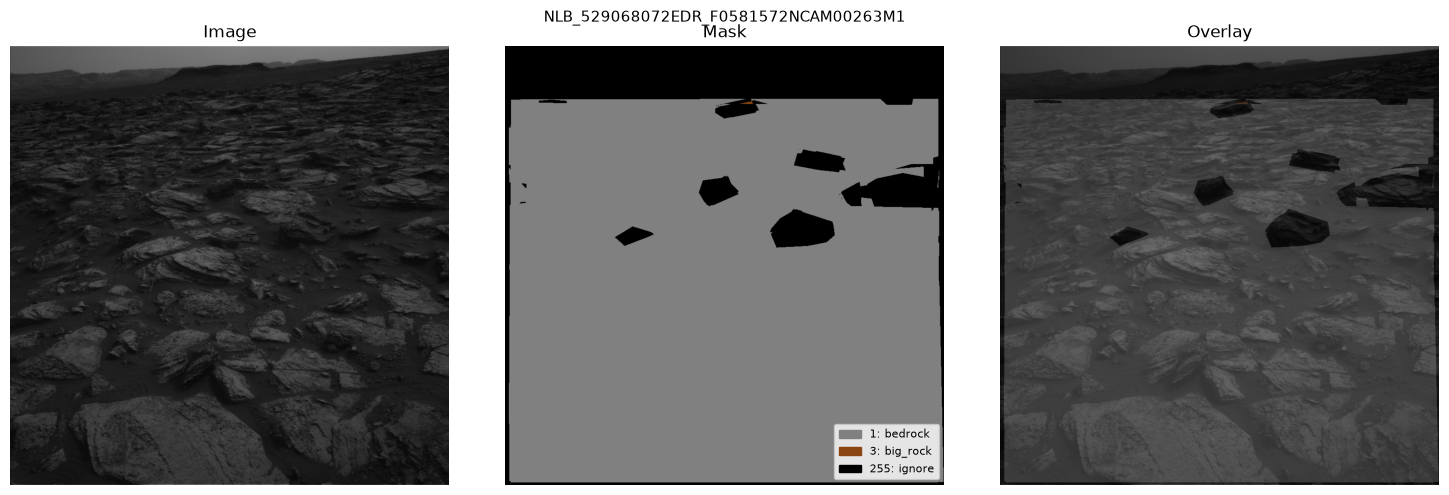


Audit sample 2/12
Dataset index:      452
Image:              C:\Users\Jacob\AI4Mars\data\raw\ai4mars\ai4mars-dataset-merged-0.6\msl\ncam\images\edr\NLA_408238743EDR_F0050754NCAM00344M1.JPG
Mask:               C:\Users\Jacob\AI4Mars\data\raw\ai4mars\ai4mars-dataset-merged-0.6\msl\ncam\labels\train\NLA_408238743EDR_F0050754NCAM00344M1.png
Big-rock pixels:    753
Big-rock fraction:  0.12%
Image  : NLA_408238743EDR_F0050754NCAM00344M1.JPG  shape=(1024, 1024, 3)  dtype=uint8
Mask   : NLA_408238743EDR_F0050754NCAM00344M1.png  shape=(1024, 1024)  dtype=int64
Label scheme: NAV
Unique class IDs in mask: [0, 1, 3, 255]

Mask class distribution (total 1048576 pixels):
  class   0 (      soil):    11942 px  (  1.1%)
  class   1 (   bedrock):   598884 px  ( 57.1%)
  class   3 (  big_rock):      753 px  (  0.1%)
  class 255 (    ignore):   436997 px  ( 41.7%)


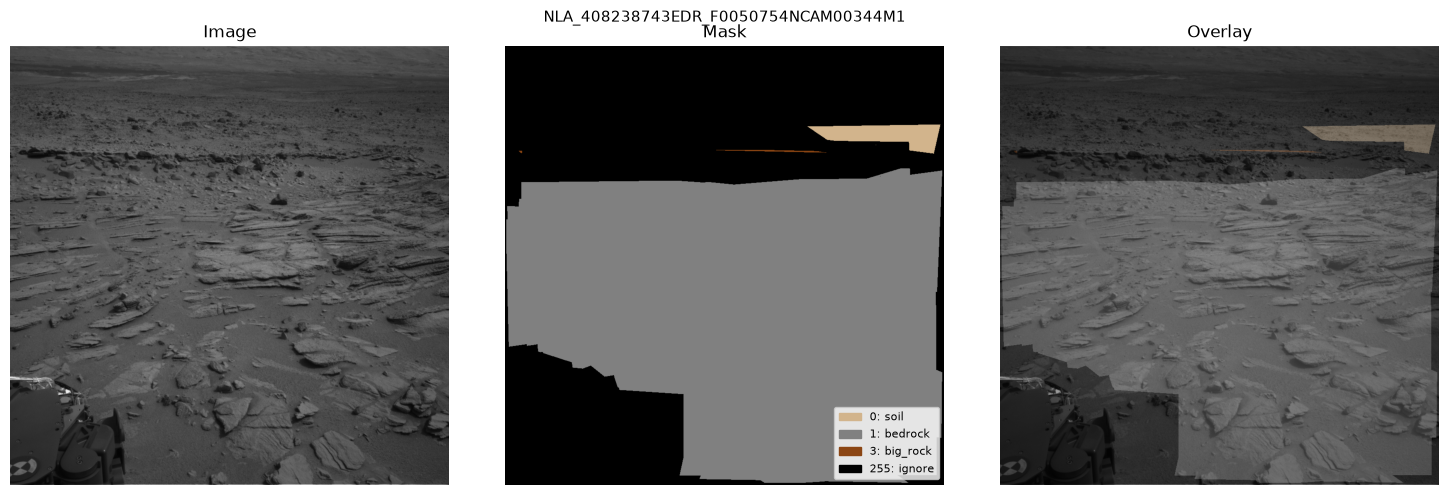


Audit sample 3/12
Dataset index:      5291
Image:              C:\Users\Jacob\AI4Mars\data\raw\ai4mars\ai4mars-dataset-merged-0.6\msl\ncam\images\edr\NLB_489560743EDR_F0481964NCAM07753M1.JPG
Mask:               C:\Users\Jacob\AI4Mars\data\raw\ai4mars\ai4mars-dataset-merged-0.6\msl\ncam\labels\train\NLB_489560743EDR_F0481964NCAM07753M1.png
Big-rock pixels:    2,648
Big-rock fraction:  0.37%
Image  : NLB_489560743EDR_F0481964NCAM07753M1.JPG  shape=(1024, 1024, 3)  dtype=uint8
Mask   : NLB_489560743EDR_F0481964NCAM07753M1.png  shape=(1024, 1024)  dtype=int64
Label scheme: NAV
Unique class IDs in mask: [0, 1, 2, 3, 255]

Mask class distribution (total 1048576 pixels):
  class   0 (      soil):   681359 px  ( 65.0%)
  class   1 (   bedrock):     2662 px  (  0.3%)
  class   2 (      sand):    24844 px  (  2.4%)
  class   3 (  big_rock):     2648 px  (  0.3%)
  class 255 (    ignore):   337063 px  ( 32.1%)


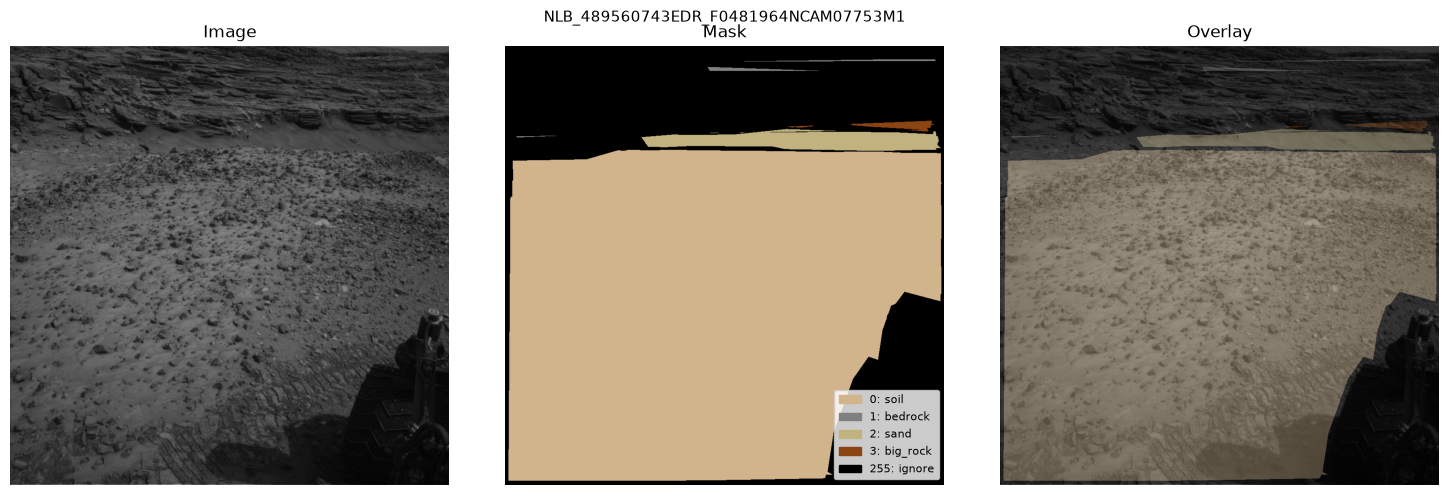


Audit sample 4/12
Dataset index:      2462
Image:              C:\Users\Jacob\AI4Mars\data\raw\ai4mars\ai4mars-dataset-merged-0.6\msl\ncam\images\edr\NLB_444809686EDR_F0260292NCAM00259M1.JPG
Mask:               C:\Users\Jacob\AI4Mars\data\raw\ai4mars\ai4mars-dataset-merged-0.6\msl\ncam\labels\train\NLB_444809686EDR_F0260292NCAM00259M1.png
Big-rock pixels:    5,103
Big-rock fraction:  0.74%
Image  : NLB_444809686EDR_F0260292NCAM00259M1.JPG  shape=(1024, 1024, 3)  dtype=uint8
Mask   : NLB_444809686EDR_F0260292NCAM00259M1.png  shape=(1024, 1024)  dtype=int64
Label scheme: NAV
Unique class IDs in mask: [0, 2, 3, 255]

Mask class distribution (total 1048576 pixels):
  class   0 (      soil):    99460 px  (  9.5%)
  class   2 (      sand):   585777 px  ( 55.9%)
  class   3 (  big_rock):     5103 px  (  0.5%)
  class 255 (    ignore):   358236 px  ( 34.2%)


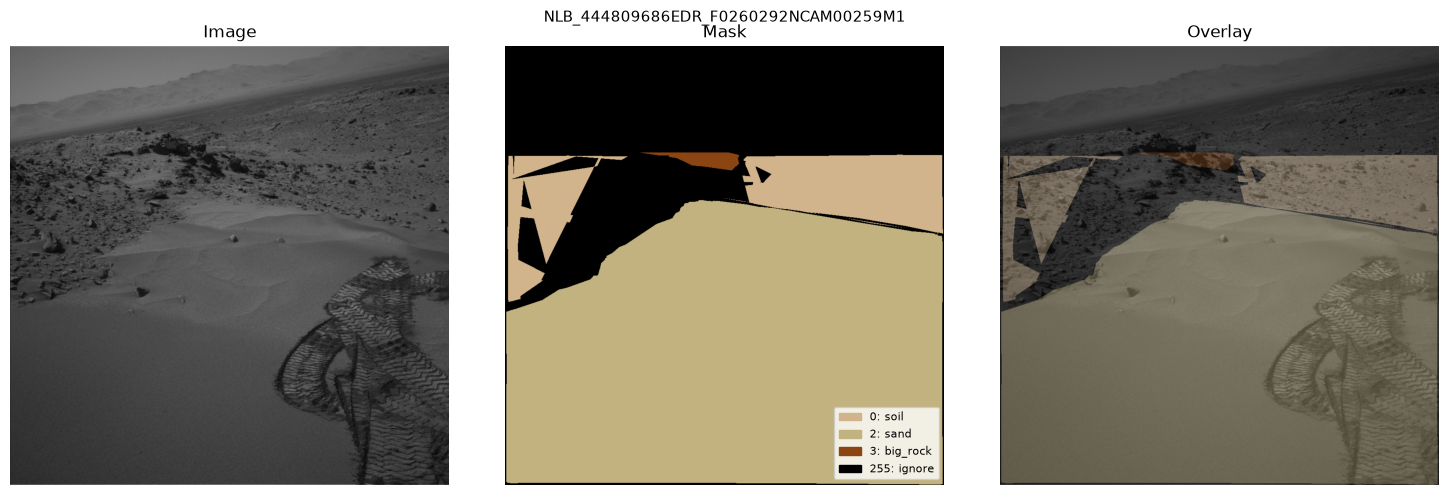


Audit sample 5/12
Dataset index:      3836
Image:              C:\Users\Jacob\AI4Mars\data\raw\ai4mars\ai4mars-dataset-merged-0.6\msl\ncam\images\edr\NLB_460434855EDR_F0400366NCAM07812M1.JPG
Mask:               C:\Users\Jacob\AI4Mars\data\raw\ai4mars\ai4mars-dataset-merged-0.6\msl\ncam\labels\train\NLB_460434855EDR_F0400366NCAM07812M1.png
Big-rock pixels:    13,254
Big-rock fraction:  1.34%
Image  : NLB_460434855EDR_F0400366NCAM07812M1.JPG  shape=(1024, 1024, 3)  dtype=uint8
Mask   : NLB_460434855EDR_F0400366NCAM07812M1.png  shape=(1024, 1024)  dtype=int64
Label scheme: NAV
Unique class IDs in mask: [2, 3, 255]

Mask class distribution (total 1048576 pixels):
  class   2 (      sand):   973489 px  ( 92.8%)
  class   3 (  big_rock):    13254 px  (  1.3%)
  class 255 (    ignore):    61833 px  (  5.9%)


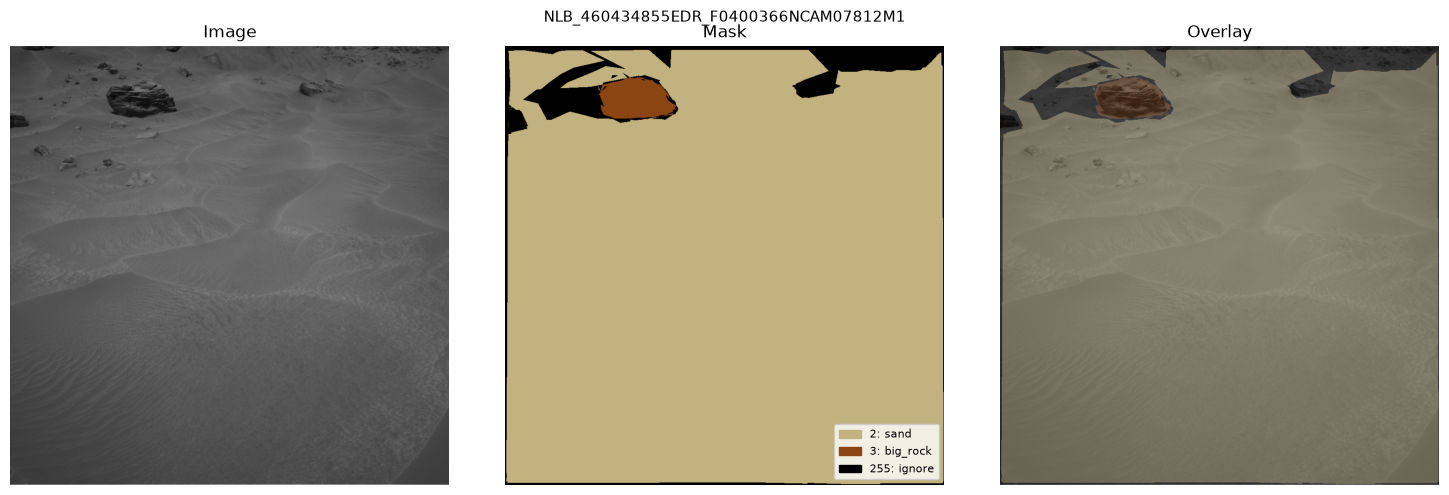


Audit sample 6/12
Dataset index:      9846
Image:              C:\Users\Jacob\AI4Mars\data\raw\ai4mars\ai4mars-dataset-merged-0.6\msl\ncam\images\edr\NLB_557199297EDR_F0652396NCAM00385M1.JPG
Mask:               C:\Users\Jacob\AI4Mars\data\raw\ai4mars\ai4mars-dataset-merged-0.6\msl\ncam\labels\train\NLB_557199297EDR_F0652396NCAM00385M1.png
Big-rock pixels:    15,536
Big-rock fraction:  2.33%
Image  : NLB_557199297EDR_F0652396NCAM00385M1.JPG  shape=(1024, 1024, 3)  dtype=uint8
Mask   : NLB_557199297EDR_F0652396NCAM00385M1.png  shape=(1024, 1024)  dtype=int64
Label scheme: NAV
Unique class IDs in mask: [1, 2, 3, 255]

Mask class distribution (total 1048576 pixels):
  class   1 (   bedrock):   381542 px  ( 36.4%)
  class   2 (      sand):   271067 px  ( 25.9%)
  class   3 (  big_rock):    15536 px  (  1.5%)
  class 255 (    ignore):   380431 px  ( 36.3%)


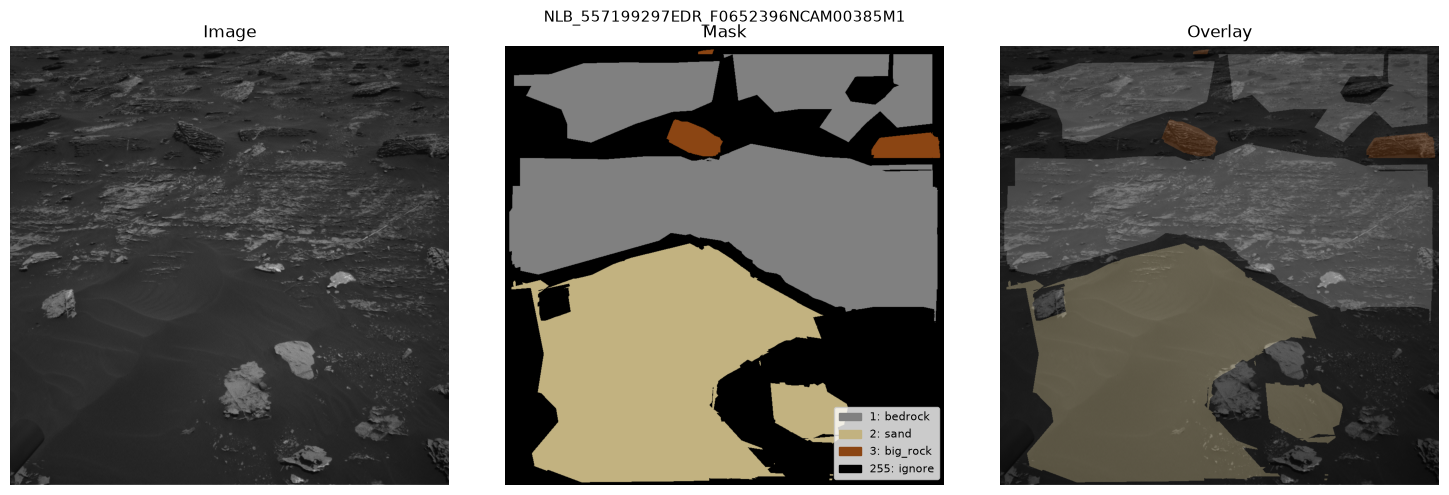


Audit sample 7/12
Dataset index:      9039
Image:              C:\Users\Jacob\AI4Mars\data\raw\ai4mars\ai4mars-dataset-merged-0.6\msl\ncam\images\edr\NLB_546993527EDR_F0623050NCAM07753M1.JPG
Mask:               C:\Users\Jacob\AI4Mars\data\raw\ai4mars\ai4mars-dataset-merged-0.6\msl\ncam\labels\train\NLB_546993527EDR_F0623050NCAM07753M1.png
Big-rock pixels:    14,540
Big-rock fraction:  3.67%
Image  : NLB_546993527EDR_F0623050NCAM07753M1.JPG  shape=(1024, 1024, 3)  dtype=uint8
Mask   : NLB_546993527EDR_F0623050NCAM07753M1.png  shape=(1024, 1024)  dtype=int64
Label scheme: NAV
Unique class IDs in mask: [1, 2, 3, 255]

Mask class distribution (total 1048576 pixels):
  class   1 (   bedrock):   325675 px  ( 31.1%)
  class   2 (      sand):    55594 px  (  5.3%)
  class   3 (  big_rock):    14540 px  (  1.4%)
  class 255 (    ignore):   652767 px  ( 62.3%)


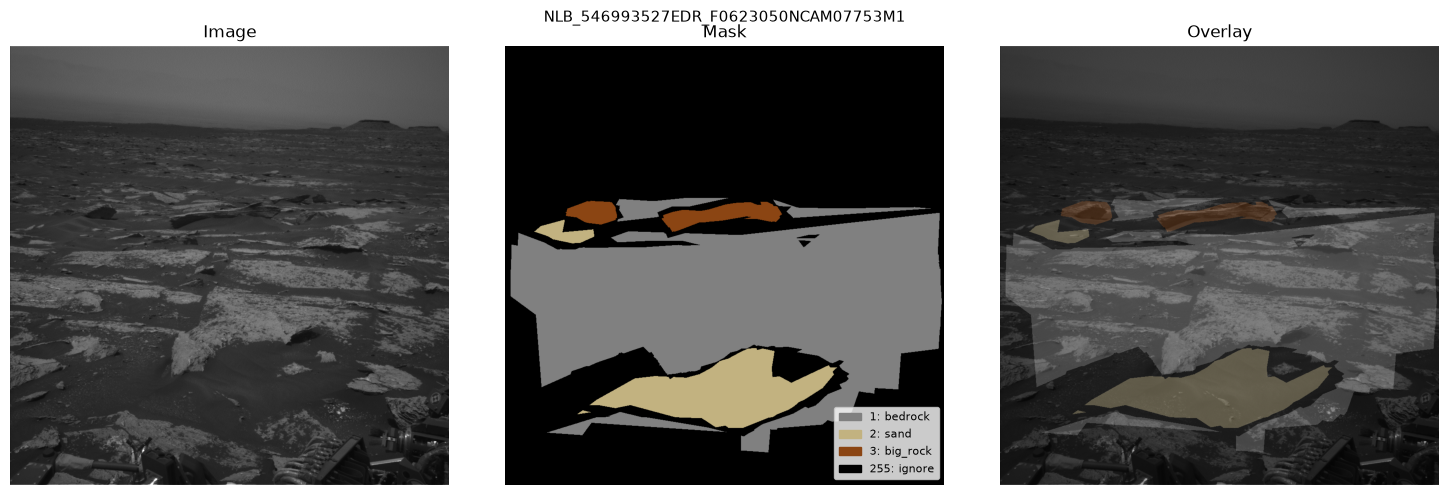


Audit sample 8/12
Dataset index:      3096
Image:              C:\Users\Jacob\AI4Mars\data\raw\ai4mars\ai4mars-dataset-merged-0.6\msl\ncam\images\edr\NLB_451296365EDR_F0311256NCAM00273M1.JPG
Mask:               C:\Users\Jacob\AI4Mars\data\raw\ai4mars\ai4mars-dataset-merged-0.6\msl\ncam\labels\train\NLB_451296365EDR_F0311256NCAM00273M1.png
Big-rock pixels:    37,472
Big-rock fraction:  5.36%
Image  : NLB_451296365EDR_F0311256NCAM00273M1.JPG  shape=(1024, 1024, 3)  dtype=uint8
Mask   : NLB_451296365EDR_F0311256NCAM00273M1.png  shape=(1024, 1024)  dtype=int64
Label scheme: NAV
Unique class IDs in mask: [1, 2, 3, 255]

Mask class distribution (total 1048576 pixels):
  class   1 (   bedrock):   315238 px  ( 30.1%)
  class   2 (      sand):   345881 px  ( 33.0%)
  class   3 (  big_rock):    37472 px  (  3.6%)
  class 255 (    ignore):   349985 px  ( 33.4%)


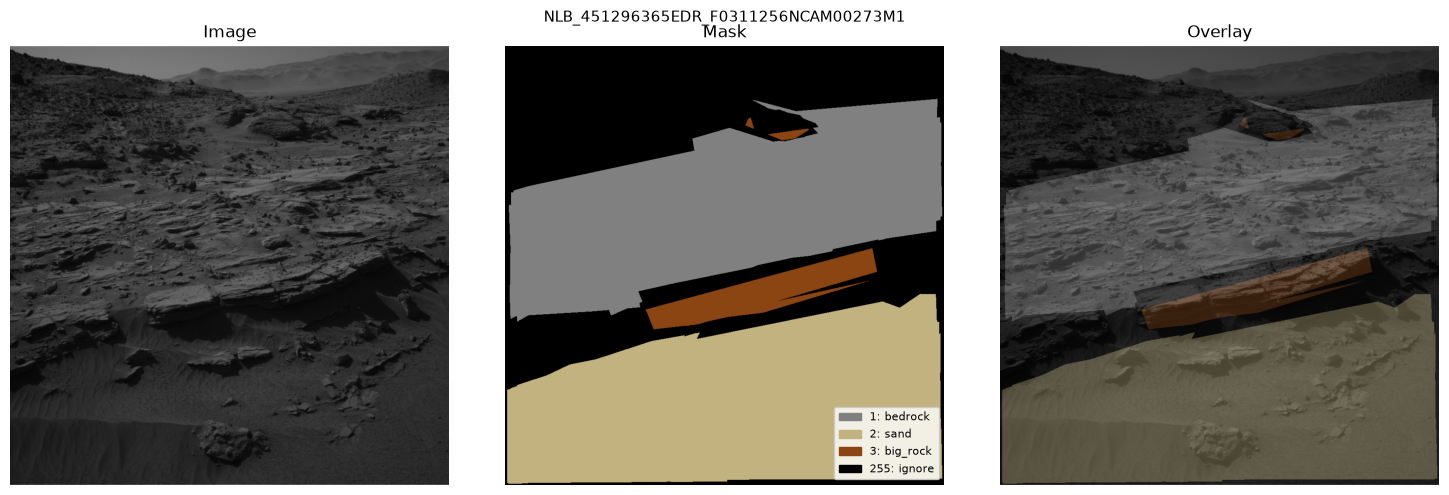


Audit sample 9/12
Dataset index:      6986
Image:              C:\Users\Jacob\AI4Mars\data\raw\ai4mars\ai4mars-dataset-merged-0.6\msl\ncam\images\edr\NLB_517253741EDR_F0541550NCAM00386M1.JPG
Mask:               C:\Users\Jacob\AI4Mars\data\raw\ai4mars\ai4mars-dataset-merged-0.6\msl\ncam\labels\train\NLB_517253741EDR_F0541550NCAM00386M1.png
Big-rock pixels:    77,780
Big-rock fraction:  9.57%
Image  : NLB_517253741EDR_F0541550NCAM00386M1.JPG  shape=(1024, 1024, 3)  dtype=uint8
Mask   : NLB_517253741EDR_F0541550NCAM00386M1.png  shape=(1024, 1024)  dtype=int64
Label scheme: NAV
Unique class IDs in mask: [1, 2, 3, 255]

Mask class distribution (total 1048576 pixels):
  class   1 (   bedrock):   473912 px  ( 45.2%)
  class   2 (      sand):   260953 px  ( 24.9%)
  class   3 (  big_rock):    77780 px  (  7.4%)
  class 255 (    ignore):   235931 px  ( 22.5%)


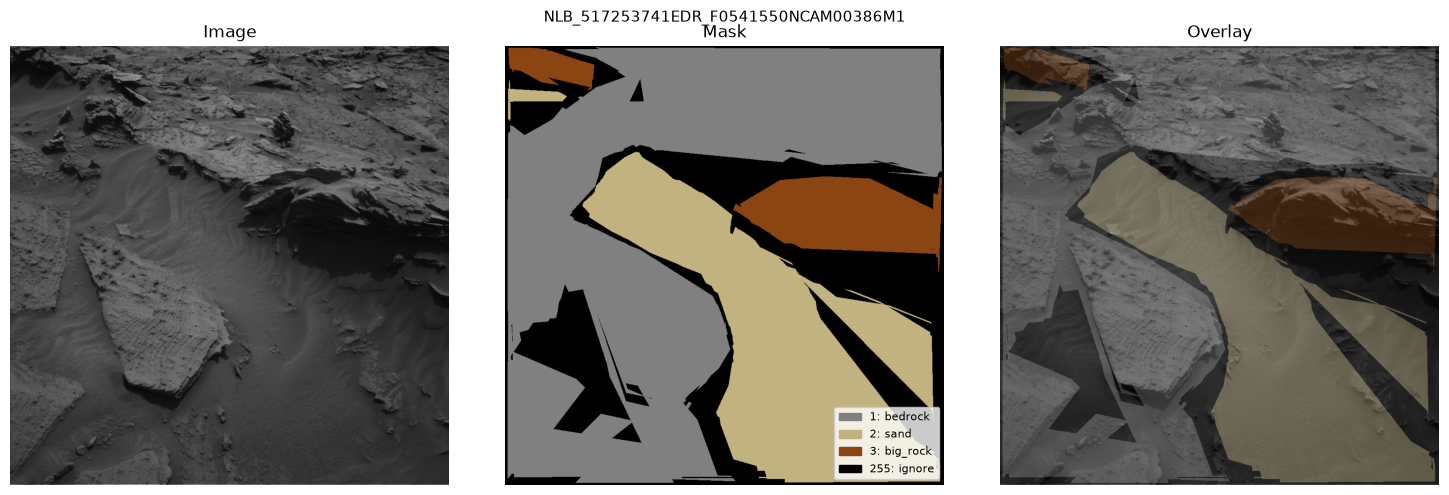


Audit sample 10/12
Dataset index:      4539
Image:              C:\Users\Jacob\AI4Mars\data\raw\ai4mars\ai4mars-dataset-merged-0.6\msl\ncam\images\edr\NLB_472071027EDR_F0442414NCAM00353M1.JPG
Mask:               C:\Users\Jacob\AI4Mars\data\raw\ai4mars\ai4mars-dataset-merged-0.6\msl\ncam\labels\train\NLB_472071027EDR_F0442414NCAM00353M1.png
Big-rock pixels:    69,893
Big-rock fraction:  14.99%
Image  : NLB_472071027EDR_F0442414NCAM00353M1.JPG  shape=(1024, 1024, 3)  dtype=uint8
Mask   : NLB_472071027EDR_F0442414NCAM00353M1.png  shape=(1024, 1024)  dtype=int64
Label scheme: NAV
Unique class IDs in mask: [1, 2, 3, 255]

Mask class distribution (total 1048576 pixels):
  class   1 (   bedrock):   161209 px  ( 15.4%)
  class   2 (      sand):   235241 px  ( 22.4%)
  class   3 (  big_rock):    69893 px  (  6.7%)
  class 255 (    ignore):   582233 px  ( 55.5%)


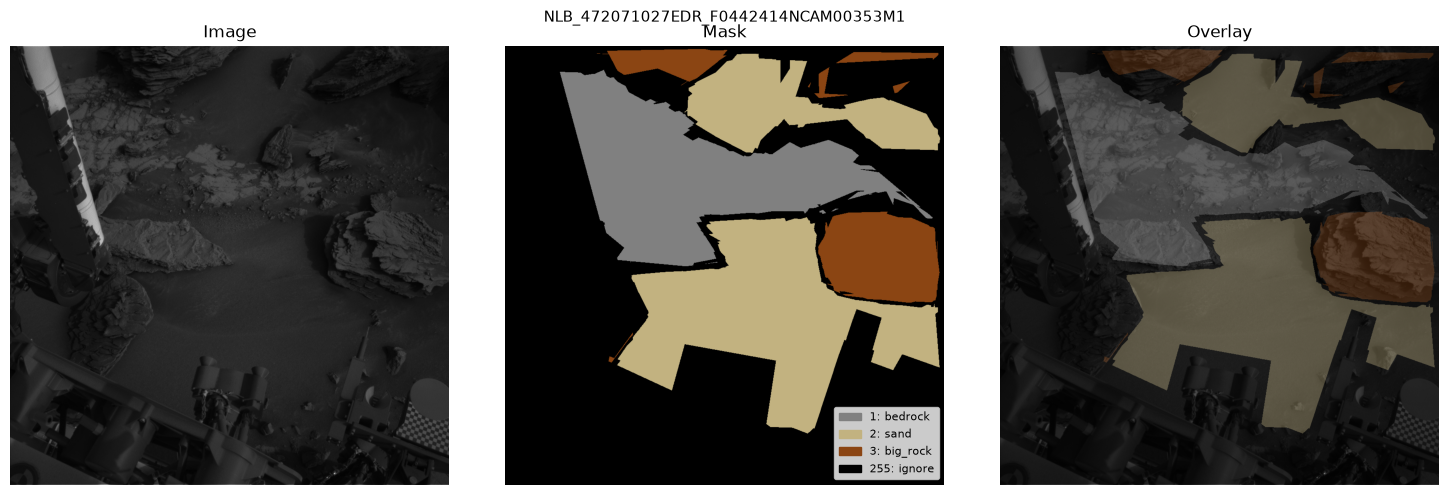


Audit sample 11/12
Dataset index:      1895
Image:              C:\Users\Jacob\AI4Mars\data\raw\ai4mars\ai4mars-dataset-merged-0.6\msl\ncam\images\edr\NLB_436560164EDR_F0220000NCAM00259M1.JPG
Mask:               C:\Users\Jacob\AI4Mars\data\raw\ai4mars\ai4mars-dataset-merged-0.6\msl\ncam\labels\train\NLB_436560164EDR_F0220000NCAM00259M1.png
Big-rock pixels:    213,548
Big-rock fraction:  31.13%
Image  : NLB_436560164EDR_F0220000NCAM00259M1.JPG  shape=(1024, 1024, 3)  dtype=uint8
Mask   : NLB_436560164EDR_F0220000NCAM00259M1.png  shape=(1024, 1024)  dtype=int64
Label scheme: NAV
Unique class IDs in mask: [0, 1, 3, 255]

Mask class distribution (total 1048576 pixels):
  class   0 (      soil):   247303 px  ( 23.6%)
  class   1 (   bedrock):   225194 px  ( 21.5%)
  class   3 (  big_rock):   213548 px  ( 20.4%)
  class 255 (    ignore):   362531 px  ( 34.6%)


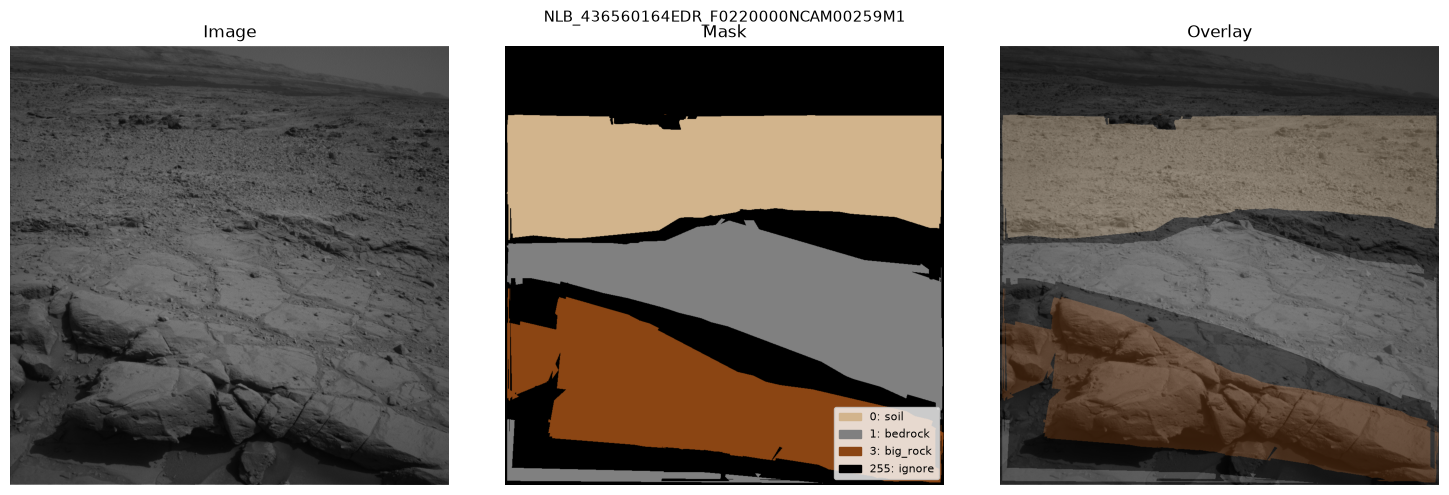


Audit sample 12/12
Dataset index:      12751
Image:              C:\Users\Jacob\AI4Mars\data\raw\ai4mars\ai4mars-dataset-merged-0.6\msl\ncam\images\edr\NLB_626010959EDR_F0771070NCAM00223M1.JPG
Mask:               C:\Users\Jacob\AI4Mars\data\raw\ai4mars\ai4mars-dataset-merged-0.6\msl\ncam\labels\train\NLB_626010959EDR_F0771070NCAM00223M1.png
Big-rock pixels:    20,531
Big-rock fraction:  100.00%
Image  : NLB_626010959EDR_F0771070NCAM00223M1.JPG  shape=(1024, 1024, 3)  dtype=uint8
Mask   : NLB_626010959EDR_F0771070NCAM00223M1.png  shape=(1024, 1024)  dtype=int64
Label scheme: NAV
Unique class IDs in mask: [3, 255]

Mask class distribution (total 1048576 pixels):
  class   3 (  big_rock):    20531 px  (  2.0%)
  class 255 (    ignore):  1028045 px  ( 98.0%)


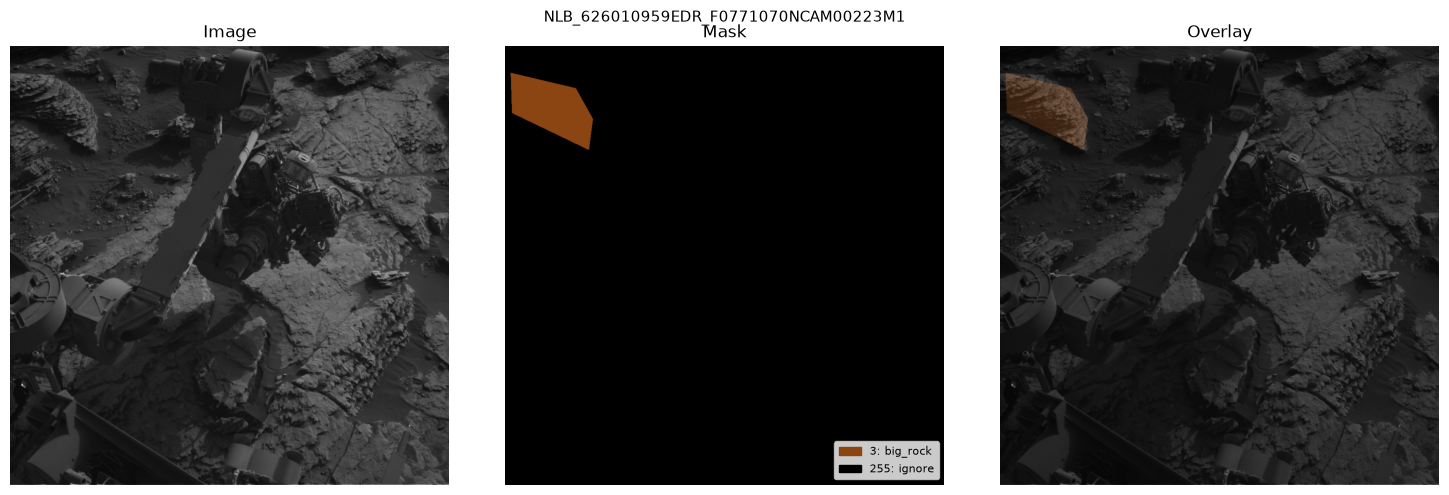

In [ ]:
for audit_number, row in enumerate(
    selected_big_rock_samples,
    start=1,
):
    print("\n" + "=" * 80)
    print(
        f"Audit sample {audit_number}/"
        f"{len(selected_big_rock_samples)}"
    )
    print(f"Dataset index:      {row['sample_idx']}")
    print(f"Image:              {row['image_path']}")
    print(f"Mask:               {row['mask_path']}")
    print(
        f"Big-rock pixels:    "
        f"{row['big_rock_pixels']:,}"
    )
    print(
        f"Big-rock fraction:  "
        f"{row['big_rock_fraction']:.2%}"
    )

    show_sample(
        row["image_path"],
        row["mask_path"],
    )

## Step 4 — Verify Batch Shapes

Always check tensor shapes **before** training.  
A shape mismatch will cause a confusing error inside the model.

In [29]:
images, masks = next(iter(train_loader))
print(f"Image batch shape : {images.shape}   (expected [B, 3, H, W])")
print(f"Mask  batch shape : {masks.shape}    (expected [B, H, W])")
print(f"Image dtype       : {images.dtype}   (expected float32)")
print(f"Mask  dtype       : {masks.dtype}    (expected int64 / long)")
print(f"Image value range : [{images.min():.3f}, {images.max():.3f}]  (expected [0, 1])")

Image batch shape : torch.Size([4, 3, 256, 256])   (expected [B, 3, H, W])
Mask  batch shape : torch.Size([4, 256, 256])    (expected [B, H, W])
Image dtype       : torch.float32   (expected float32)
Mask  dtype       : torch.int64    (expected int64 / long)
Image value range : [0.016, 0.651]  (expected [0, 1])


## Step 5 — Define a Stronger Pretrained Segmentation Model

For the first real baseline, use a pretrained U-Net encoder so the model starts with useful low-level visual features (edges, textures) instead of learning everything from scratch.

In [30]:
import segmentation_models_pytorch as smp

# Use a lighter encoder on CPU to keep iterations practical.
device = get_device()
encoder_name = "mobilenet_v2" if device.type == "cpu" else "resnet34"

model = smp.Unet(
    encoder_name=encoder_name,
    encoder_weights="imagenet",
    in_channels=3,
    classes=NUM_CLASSES,
).to(device)

# Quick shape check before training
dummy = torch.randn(2, 3, IMAGE_SIZE[1], IMAGE_SIZE[0]).to(device)
out = model(dummy)
print(f"Encoder: {encoder_name}")
print(f"Model output shape: {out.shape}   (expected [2, {NUM_CLASSES}, {IMAGE_SIZE[1]}, {IMAGE_SIZE[0]}])")

num_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {num_params:,}")

Using device: cuda
Encoder: resnet34
Model output shape: torch.Size([2, 4, 256, 256])   (expected [2, 4, 256, 256])
Model parameters: 24,436,804


## Step 6 — Loss Function and Optimiser

In [31]:
# Weighted cross-entropy to counter class imbalance using the empirical class
# distribution computed above.
weights = class_weights.to(device)
loss_fn = nn.CrossEntropyLoss(weight=weights.to(device), ignore_index=IGNORE_INDEX)

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
print(f"Class weights: {weights.tolist()}")

Class weights: [0.08865173906087875, 0.06842251121997833, 0.28028181195259094, 3.5626440048217773]


## Reproducibility Log

Record the key settings needed to reproduce the baseline experiment and the
saved checkpoint.

In [32]:
PREPROCESSING_CONFIG = {
    "image_size": list(IMAGE_SIZE),
    "require_original_shape_match": True,
    "label_scheme": "NAV",
}
LOSS_NAME = "CrossEntropyLoss"
LOSS_WEIGHTS = [float(value) for value in class_weights.tolist()]
MODEL_NAME = f"Unet/{encoder_name}"
RUN_CONFIG = {
    "model_name": MODEL_NAME,
    "epochs": int(NUM_EPOCHS),
    "batch_size": int(BATCH_SIZE),
    "learning_rate": float(LEARNING_RATE),
    "seed": int(TRAIN_SPLIT_SEED),
    "preprocessing": PREPROCESSING_CONFIG,
    "loss_name": LOSS_NAME,
    "loss_weights": LOSS_WEIGHTS,
}

print("Prepared canonical provenance config for checkpoint + run record:")
print(f"  dataset_manifest: {DATASET_MANIFEST}")
for split_name, split_path in sorted(split_manifest_paths.items()):
    print(f"  {split_name:20s} sha256={sha256_file(split_path)}")
print(f"  model_name      : {MODEL_NAME}")
print(f"  loss_name       : {LOSS_NAME}")
print(f"  loss_weights    : {LOSS_WEIGHTS}")

Prepared canonical provenance config for checkpoint + run record:
  dataset_manifest: C:\Users\Jacob\AI4Mars\artifacts\manifests\ai4mars_dataset_manifest.csv
  test_min1_100agree   sha256=e7d678a972e73ebebe97fe27f06112f49b98e6e51cac2c8d408870b69f2dda03
  test_min2_100agree   sha256=cce5bc6081c4cd7e1d41871abc64d4b39978d2d44dd2e442a8526ccdc9536af0
  test_min3_100agree   sha256=5dc7486be51e35ae87e2c8d13ad5a8265c5a7dcc4bb7b84836b6930907ae6531
  train                sha256=f3e5e8d2b196baa1424e30cfd73c1984f5a00cb77294e76d8443d8834d16ab9e
  val                  sha256=8000de430defd21aa19f043c17c979d648a567995344cc84f60880fb4b32bc23
  model_name      : Unet/resnet34
  loss_name       : CrossEntropyLoss
  loss_weights    : [0.08865173906087875, 0.06842251121997833, 0.28028181195259094, 3.5626440048217773]


## Step 7 — Training Loop

In [34]:
from time import perf_counter

from src.research_console.run_store import RunLogger
from src.research_console.schema import (
    ModelRecord,
    ProtocolRecord,
    ProvenanceRecord,
    RunMetadata,
    SplitRole,
    TrainingRecord,
)

CLASS_NAMES = ["soil", "bedrock", "sand", "big_rock"]
run_id = f"msl_navcam_v1_weighted_unet_epoch{NUM_EPOCHS:02d}"
run_logger = RunLogger(
    PROJECT_ROOT / "outputs" / "runs",
    RunMetadata(
        run_id=run_id,
        experiment_name="MSL NavCam weighted U-Net baseline",
        tags=["ai4mars", "msl", "navcam", "baseline", "weighted-loss"],
        researcher_notes="Iterative model selection uses only the crowdsourced validation split.",
        provenance=ProvenanceRecord(
            dataset_name="AI4Mars",
            dataset_version="ai4mars-dataset-merged-0.6",
            dataset_manifest_sha256=sha256_file(DATASET_MANIFEST),
            split_manifest_hashes={
                name: sha256_file(path) for name, path in split_manifest_paths.items()
            },
            split_role=SplitRole.CROWDSOURCED_VALIDATION,
            protocol=ProtocolRecord(
                valid=True,
                notes=[
                    "MSL NavCam NAV scope is fixed by canonical manifests.",
                    "Expert gold test splits remain sealed during iterative selection.",
                ],
            ),
            random_seeds={"split": int(TRAIN_SPLIT_SEED)},
        ),
        model=ModelRecord(
            name="Unet",
            encoder=encoder_name,
            pretrained_weights="imagenet",
            parameter_count=sum(parameter.numel() for parameter in model.parameters()),
            input_resolution=tuple(IMAGE_SIZE),
        ),
        training=TrainingRecord(
            optimizer="Adam",
            learning_rate=float(LEARNING_RATE),
            class_weights=LOSS_WEIGHTS,
            loss=LOSS_NAME,
            batch_size=int(BATCH_SIZE),
            epochs=int(NUM_EPOCHS),
            precision_mode="float32",
        ),
    ),
)

run_logger.start()
try:
    for epoch in range(1, NUM_EPOCHS + 1):
        print(f"\nEpoch {epoch}/{NUM_EPOCHS}")
        print("-" * 40)
        epoch_started_at = perf_counter()

        train_loss = train_one_epoch(
            model,
            train_loader,
            optimizer,
            loss_fn,
            device,
            epoch=epoch,
            run_logger=run_logger,
        )
        val_metrics = evaluate(
            model,
            val_loader,
            loss_fn,
            device,
            num_classes=NUM_CLASSES,
            ignore_index=IGNORE_INDEX,
            return_per_class_iou=True,
            return_detailed_metrics=True,
            epoch=epoch,
            train_loss=train_loss,
            learning_rate=optimizer.param_groups[0]["lr"],
            epoch_duration_seconds=perf_counter() - epoch_started_at,
            run_logger=run_logger,
        )

        print(f"  Train loss : {train_loss:.4f}")
        print(f"  Val loss   : {val_metrics['val_loss']:.4f}")
        print(f"  Pixel acc  : {val_metrics['pixel_acc']:.4f}")
        print(f"  Mean IoU   : {val_metrics['mean_iou']:.4f}")

        per_class_iou = val_metrics["per_class_iou"]
        print("  Per-class IoU:")
        valid_scores = []
        for class_name, score in zip(CLASS_NAMES, per_class_iou):
            if score is None:
                print(f"    - {class_name:8s}: n/a")
            else:
                print(f"    - {class_name:8s}: {score:.4f}")
                valid_scores.append((class_name, score))

        if valid_scores:
            hardest_class, hardest_score = min(valid_scores, key=lambda item: item[1])
            print(f"  Hardest class this epoch: {hardest_class} (IoU={hardest_score:.4f})")
except BaseException as error:
    run_logger.fail(error)
    raise
else:
    run_logger.finish()
    print(f"Wrote dashboard run record to {run_logger.run_dir}")


Epoch 1/20
----------------------------------------
  Batch 10/3236  loss=1.3412
  Batch 20/3236  loss=1.2002
  Batch 30/3236  loss=1.4011
  Batch 40/3236  loss=1.1976
  Batch 50/3236  loss=1.0073
  Batch 60/3236  loss=0.7869
  Batch 70/3236  loss=1.0638
  Batch 80/3236  loss=0.8537
  Batch 90/3236  loss=0.9287
  Batch 100/3236  loss=1.1975
  Batch 110/3236  loss=0.9847
  Batch 120/3236  loss=0.6407
  Batch 130/3236  loss=1.0193
  Batch 140/3236  loss=0.6783
  Batch 150/3236  loss=0.9710
  Batch 160/3236  loss=2.3476
  Batch 170/3236  loss=0.8246
  Batch 180/3236  loss=0.8574
  Batch 190/3236  loss=0.9394
  Batch 200/3236  loss=1.0644
  Batch 210/3236  loss=0.7886
  Batch 220/3236  loss=0.8244
  Batch 230/3236  loss=1.0326
  Batch 240/3236  loss=0.7471
  Batch 250/3236  loss=0.4954
  Batch 260/3236  loss=0.5849
  Batch 270/3236  loss=1.6149
  Batch 280/3236  loss=0.7922
  Batch 290/3236  loss=0.8749
  Batch 300/3236  loss=1.1360
  Batch 310/3236  loss=1.1893
  Batch 320/3236  loss=0.8

KeyboardInterrupt: 

## Step 8 — Save Checkpoint

In [35]:
checkpoint_metadata = build_checkpoint_metadata(
    project_root=PROJECT_ROOT,
    dataset_manifest_path=DATASET_MANIFEST,
    split_manifest_paths=split_manifest_paths,
    active_split_name="val",
    preprocessing=PREPROCESSING_CONFIG,
    loss_name=LOSS_NAME,
    loss_weights=LOSS_WEIGHTS,
    model_name=MODEL_NAME,
    seed=TRAIN_SPLIT_SEED,
)

checkpoint_path = MODELS_DIR / "weighted_unet_epoch03.pth"
save_checkpoint(
    model,
    optimizer,
    epoch=NUM_EPOCHS,
    path=checkpoint_path,
    metadata=checkpoint_metadata,
)

run_id = f"msl_navcam_v1_weighted_unet_epoch{NUM_EPOCHS:02d}"
run_dir = ARTIFACTS_DIR / "runs" / run_id
metrics_payload = {
    "epoch": int(NUM_EPOCHS),
    "train_loss": float(train_loss),
    "val_loss": float(val_metrics["val_loss"]),
    "pixel_acc": float(val_metrics["pixel_acc"]),
    "mean_iou": float(val_metrics["mean_iou"]),
    "finite_loss_batches": int(val_metrics["finite_loss_batches"]),
    "skipped_all_ignore_loss_batches": int(val_metrics["skipped_all_ignore_loss_batches"]),
}
if val_metrics.get("per_class_iou") is not None:
    metrics_payload["per_class_iou"] = [
        None if value is None else float(value)
        for value in val_metrics["per_class_iou"]
    ]

config_payload = RUN_CONFIG
environment_text = "\n".join([
    f"python={sys.version}",
    f"platform={platform.platform()}",
    f"git_commit={checkpoint_metadata['git_commit_sha']}",
    f"requirements_sha256={checkpoint_metadata['dependency_lock_hash']}",
]) + "\n"
write_run_record(
    run_dir,
    config=config_payload,
    dataset_manifest_path=DATASET_MANIFEST,
    split_manifest_paths=split_manifest_paths,
    metrics=metrics_payload,
    environment_text=environment_text,
)
print(f"Saved checkpoint to {checkpoint_path}")
print(f"Wrote lightweight run record to {run_dir}")

Checkpoint saved -> C:\Users\Jacob\AI4Mars\models\weighted_unet_epoch03.pth
Saved checkpoint to C:\Users\Jacob\AI4Mars\models\weighted_unet_epoch03.pth
Wrote lightweight run record to C:\Users\Jacob\AI4Mars\artifacts\runs\msl_navcam_v1_weighted_unet_epoch20


## Next Steps

- Open `04_evaluation_error_analysis.ipynb` to load the checkpoint and analyse predictions.
- Run a cleaner experiment series next:
    - **Baseline:** U-Net with a ResNet34 encoder.
    - **Alternative encoder:** U-Net with EfficientNet if it fits local hardware.
    - **Alternative decoder family:** DeepLabV3+ for stronger context aggregation.
    - **Loss experiments:** Dice, Focal, or CE+Dice hybrids.